# Rollout Analysis
Plot actual vs target joint positions per joint from a `ur_rtde_real_time.py` NPZ log.

In [1]:
import numpy as np
import yaml
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

joint_names = ["shoulder_pan", "shoulder_lift", "elbow", "wrist_1", "wrist_2", "wrist_3"]


def analyze(npz_path, ds=5):
    """Plot actual vs target vs reference joint positions and per-joint errors."""
    npz_path = Path(npz_path)
    d = np.load(npz_path)
    actual = d["actual_q"]
    expected = d["expected_q"]
    target = d["target_q"]
    steps = d["steps"]
    title = npz_path.stem

    # Load planner's joint targets from the trajectory file (path stored in env.yaml)
    run_dir = npz_path.parent.parent
    env_yaml = run_dir / "params" / "env.yaml"
    with open(env_yaml, "r") as f:
        env_cfg = yaml.unsafe_load(f)
    traj_path = env_cfg["trajectory_path"]
    if not Path(traj_path).is_absolute():
        traj_path = run_dir.parent.parent.parent.parent / traj_path  # relative to repo root
    traj = np.load(traj_path)
    joints_target_full = traj["joints_target"] if "joints_target" in traj.files else traj["joints_target_l"]
    joints_full = traj["joints"] if "joints" in traj.files else traj["joints_l"]

    # Mirror the control thread's interpolation: starts from the planned initial joint
    # position (joints[0]), then transitions to joints_target[0] over the first 10 steps,
    # then to joints_target[1] over the next 10, etc. We prepend joints[0] so the
    # interpolation is uniform: trajectory point i lives at step (i+1)*10.
    decimation = 10
    ref_points = np.vstack([joints_full[0:1], joints_target_full])  # (T+1, 6)
    traj_x = np.arange(len(ref_points)) * decimation  # 0, 10, 20, ...
    # Generate ref_target across the full trajectory (independent of rollout step count)
    ref_steps = np.arange(traj_x[-1] + 1)
    ref_target = np.empty((len(ref_steps), ref_points.shape[1]))
    for j in range(ref_points.shape[1]):
        ref_target[:, j] = np.interp(ref_steps, traj_x, ref_points[:, j])

    print(f"{title}: {len(steps)} rollout steps, {len(ref_steps)} ref steps, gain={float(d['gain'])}, lookahead={float(d['lookahead_time'])}, action_scale={float(d['action_scale'])}")

    # Position plot
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    for i, (ax, name) in enumerate(zip(axes.flat, joint_names)):
        ax.plot(steps[::ds], expected[::ds, i], label='reference q', color='gray', linestyle='--', alpha=0.7)
        ax.plot(ref_steps[::ds], ref_target[::ds, i], label='reference target', color='tab:green', linestyle=':', alpha=0.8)
        ax.plot(steps[::ds], target[::ds, i], label='policy target', color='tab:orange', alpha=0.8)
        ax.plot(steps[::ds], actual[::ds, i], label='actual', color='tab:blue', alpha=0.8)
        ax.set_title(f"joint {i}: {name}", fontsize=10)
        ax.set_ylabel('position (rad)')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8, loc='best')
    axes[-1, 0].set_xlabel('step (500Hz)')
    axes[-1, 1].set_xlabel('step (500Hz)')
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()

    # Error plot — only over rollout steps
    n = min(len(steps), len(ref_steps))
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    for i, (ax, name) in enumerate(zip(axes.flat, joint_names)):
        ax.plot(steps[:n:ds], actual[:n:ds, i] - expected[:n:ds, i], label='actual - reference q', color='gray', alpha=0.7)
        ax.plot(steps[:n:ds], target[:n:ds, i] - ref_target[:n:ds, i], label='policy - reference target (residual)', color='tab:green', alpha=0.7)
        ax.axhline(0, color='k', linewidth=0.5)
        ax.set_title(f"joint {i}: {name}", fontsize=10)
        ax.set_ylabel('error (rad)')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8, loc='best')
    axes[-1, 0].set_xlabel('step (500Hz)')
    axes[-1, 1].set_xlabel('step (500Hz)')
    fig.suptitle(f"Per-joint error — {title}", fontsize=11)
    plt.tight_layout()

real_gain400.0_la0.05_as0.0: 1449 rollout steps, 1991 ref steps, gain=400.0, lookahead=0.05, action_scale=0.0


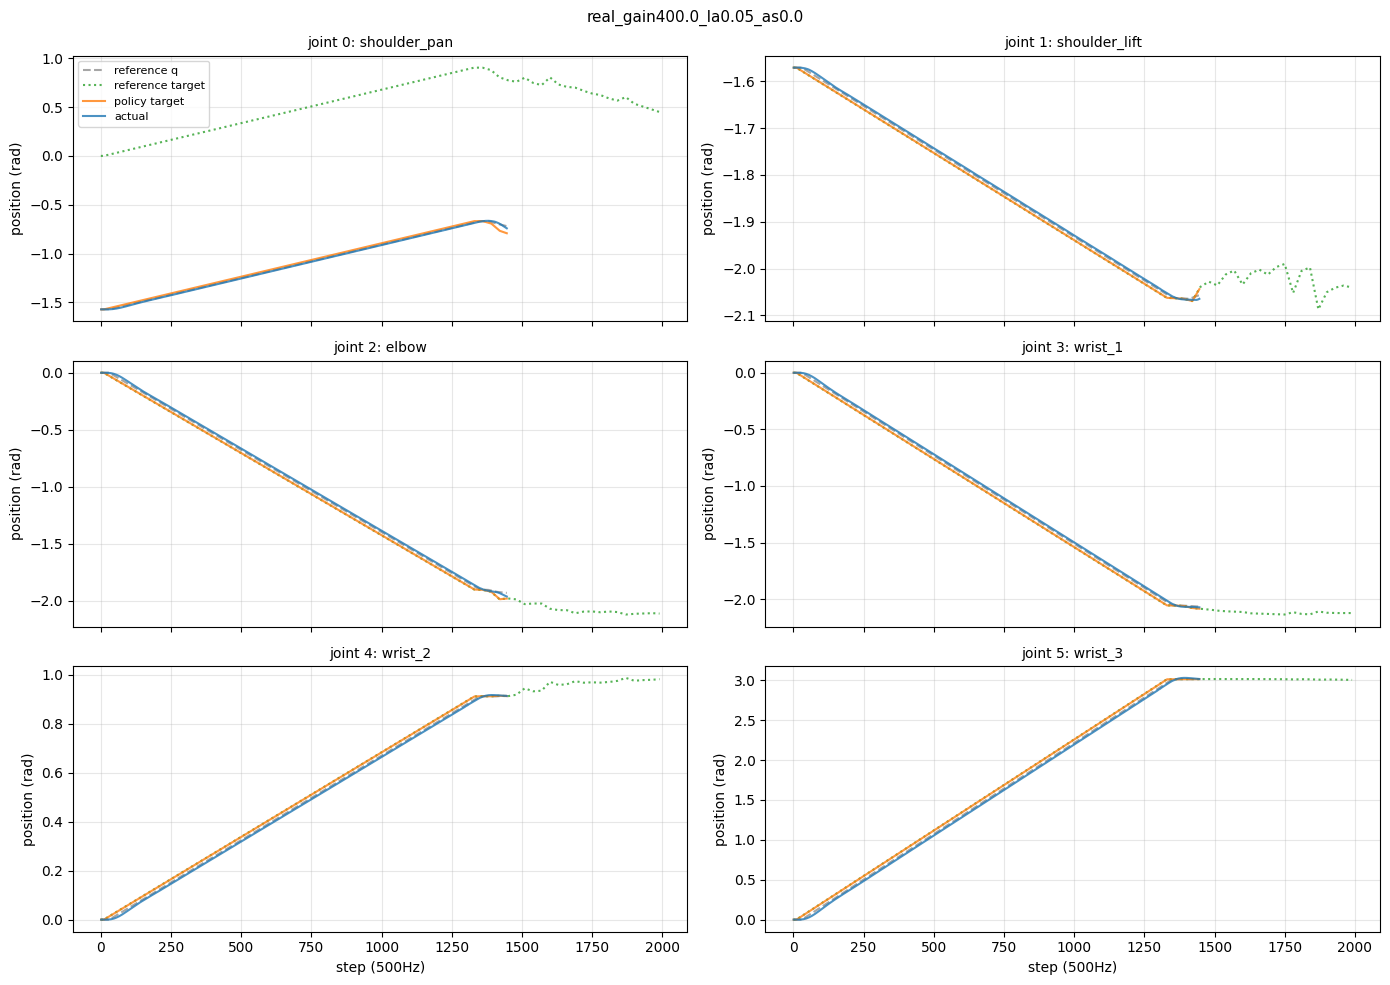

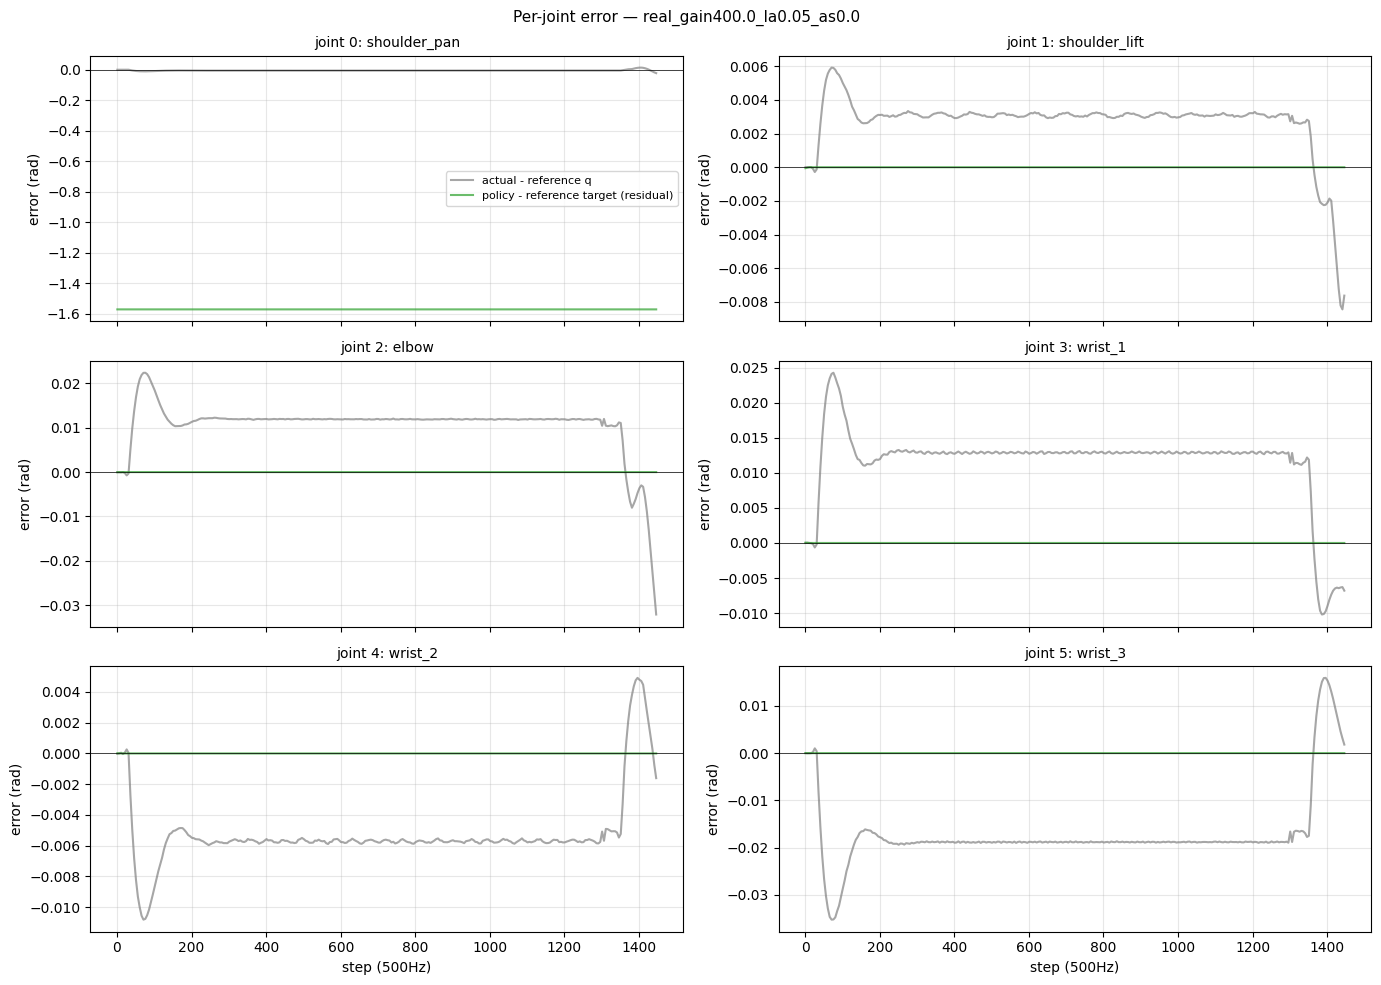

In [2]:
analyze("../logs/rsl_rl/boxpush/2026-04-09_13-03-39_kp150.0_kd22.50_scale0.05/ur_rtde_logs/real_gain400.0_la0.05_as0.0.npz")

real_gain400.0_la0.05: 1981 rollout steps, 1991 ref steps, gain=400.0, lookahead=0.05, action_scale=0.05


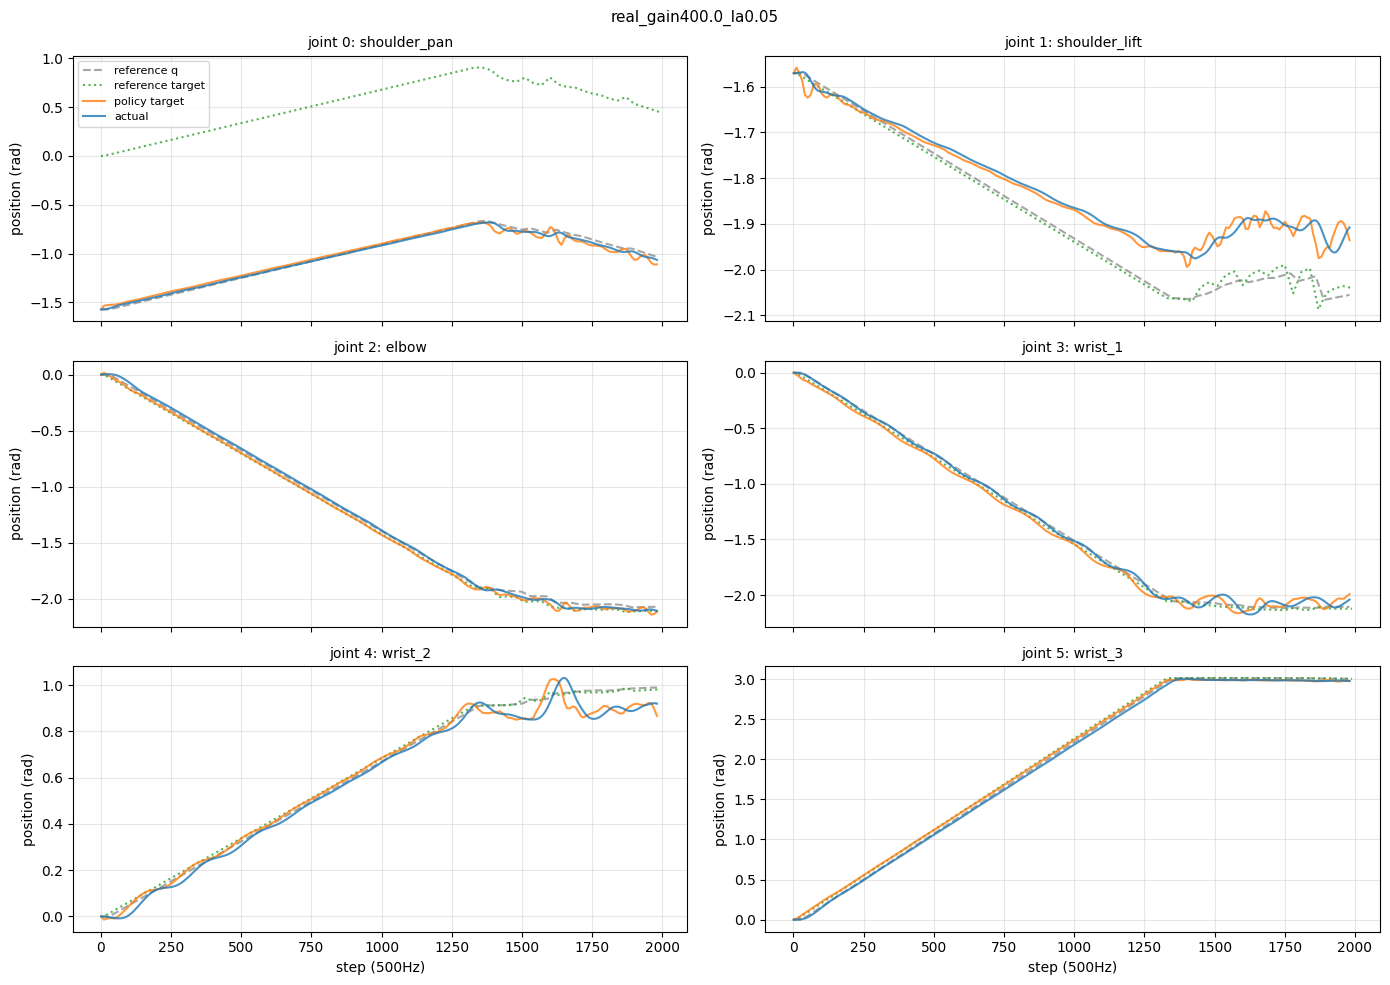

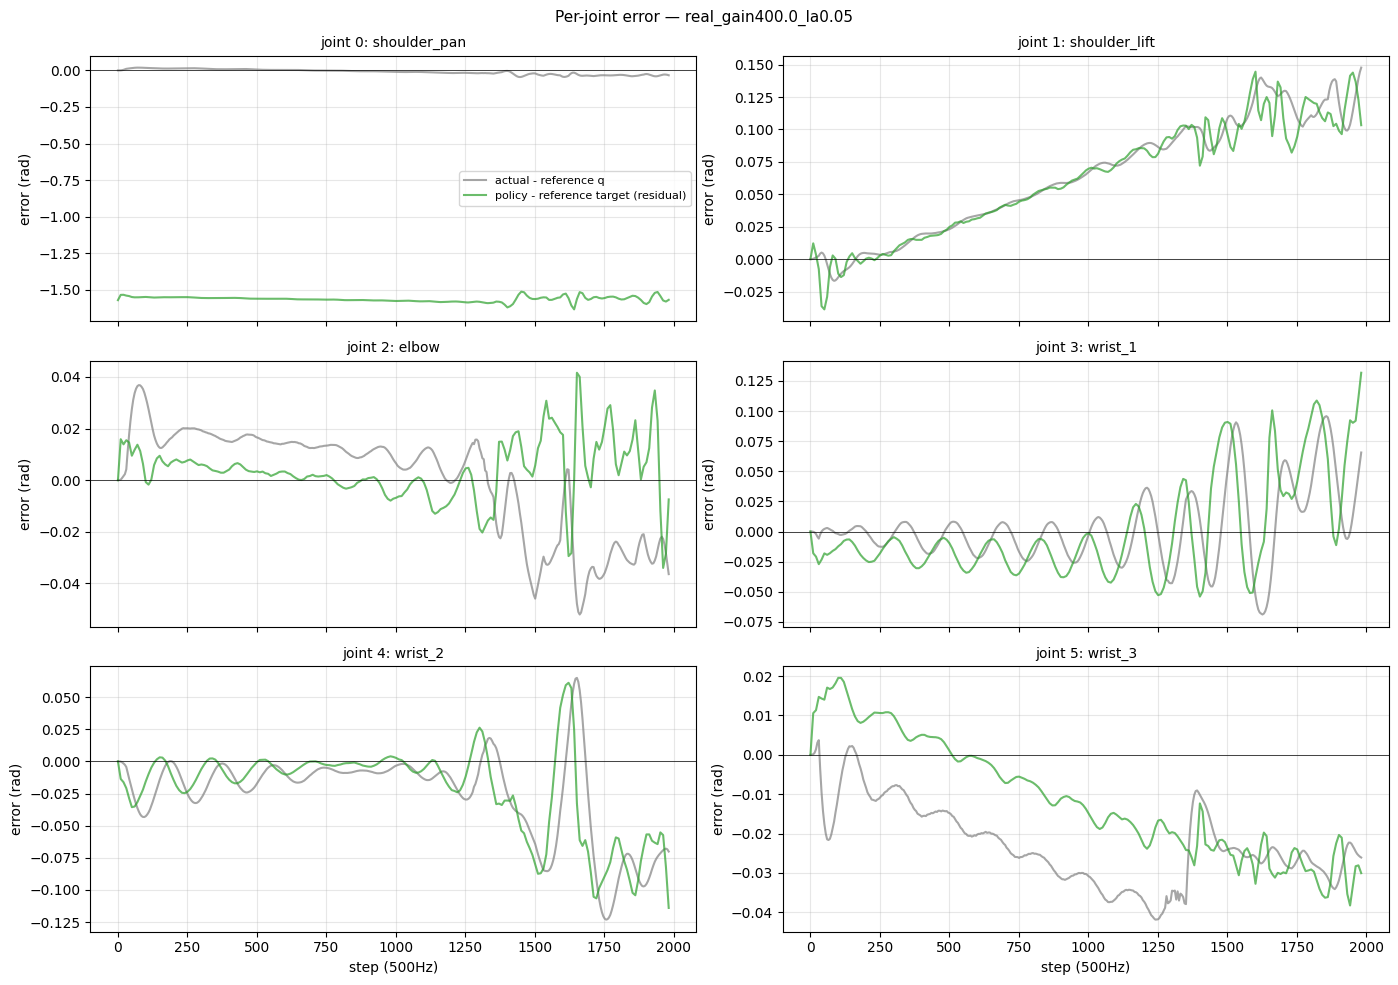

In [3]:
analyze("../logs/rsl_rl/boxpush/2026-04-09_13-03-39_kp150.0_kd22.50_scale0.05/ur_rtde_logs/real_gain400.0_la0.05.npz")

real_gain400.0_la0.1: 1981 rollout steps, 1991 ref steps, gain=400.0, lookahead=0.1, action_scale=0.05


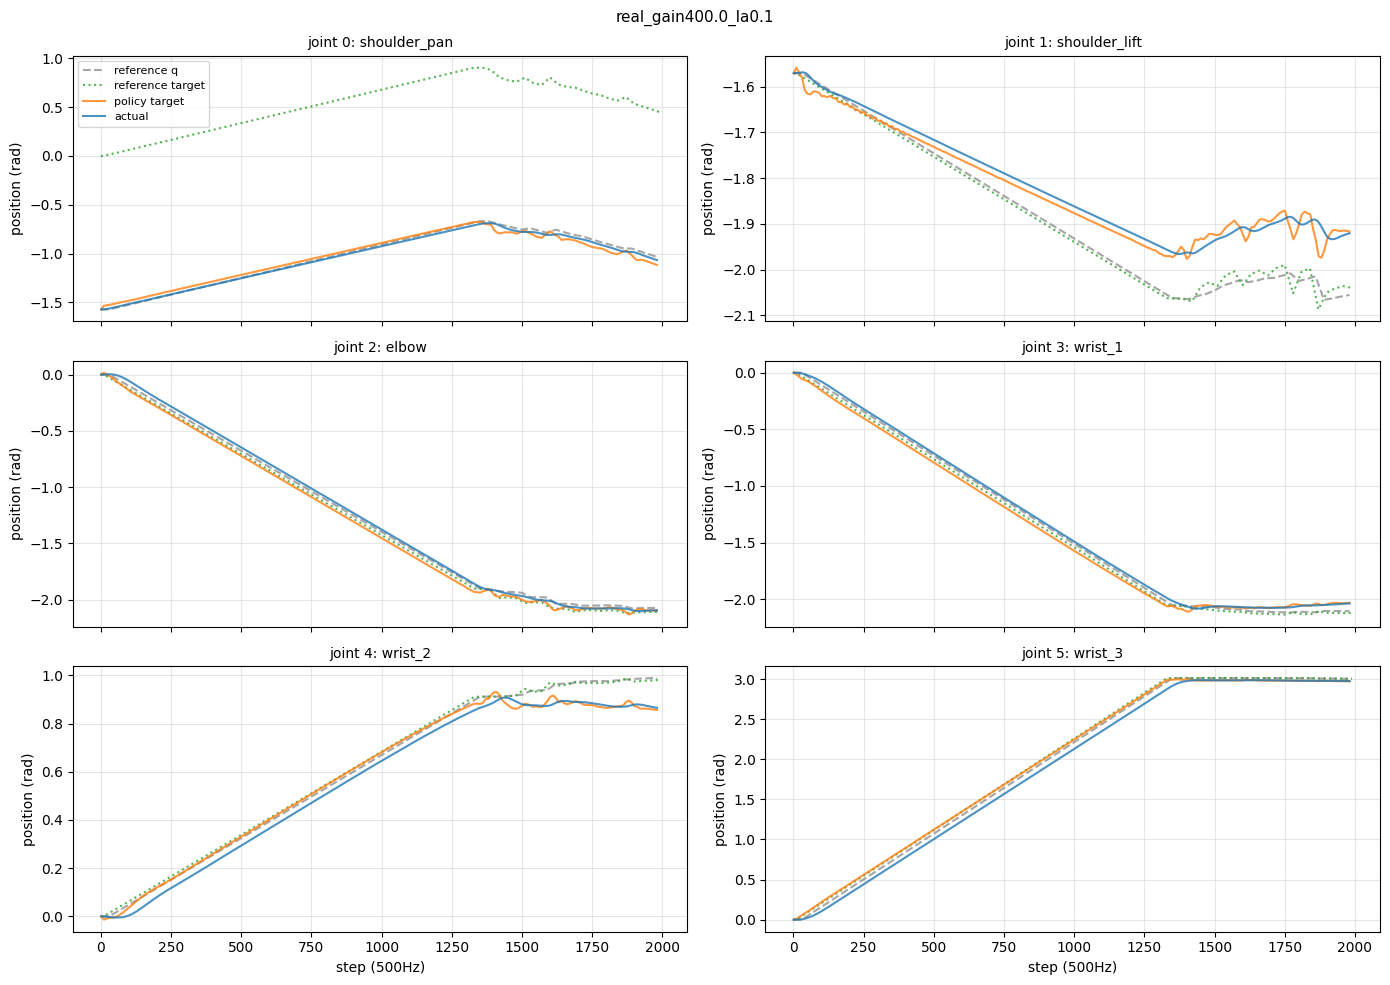

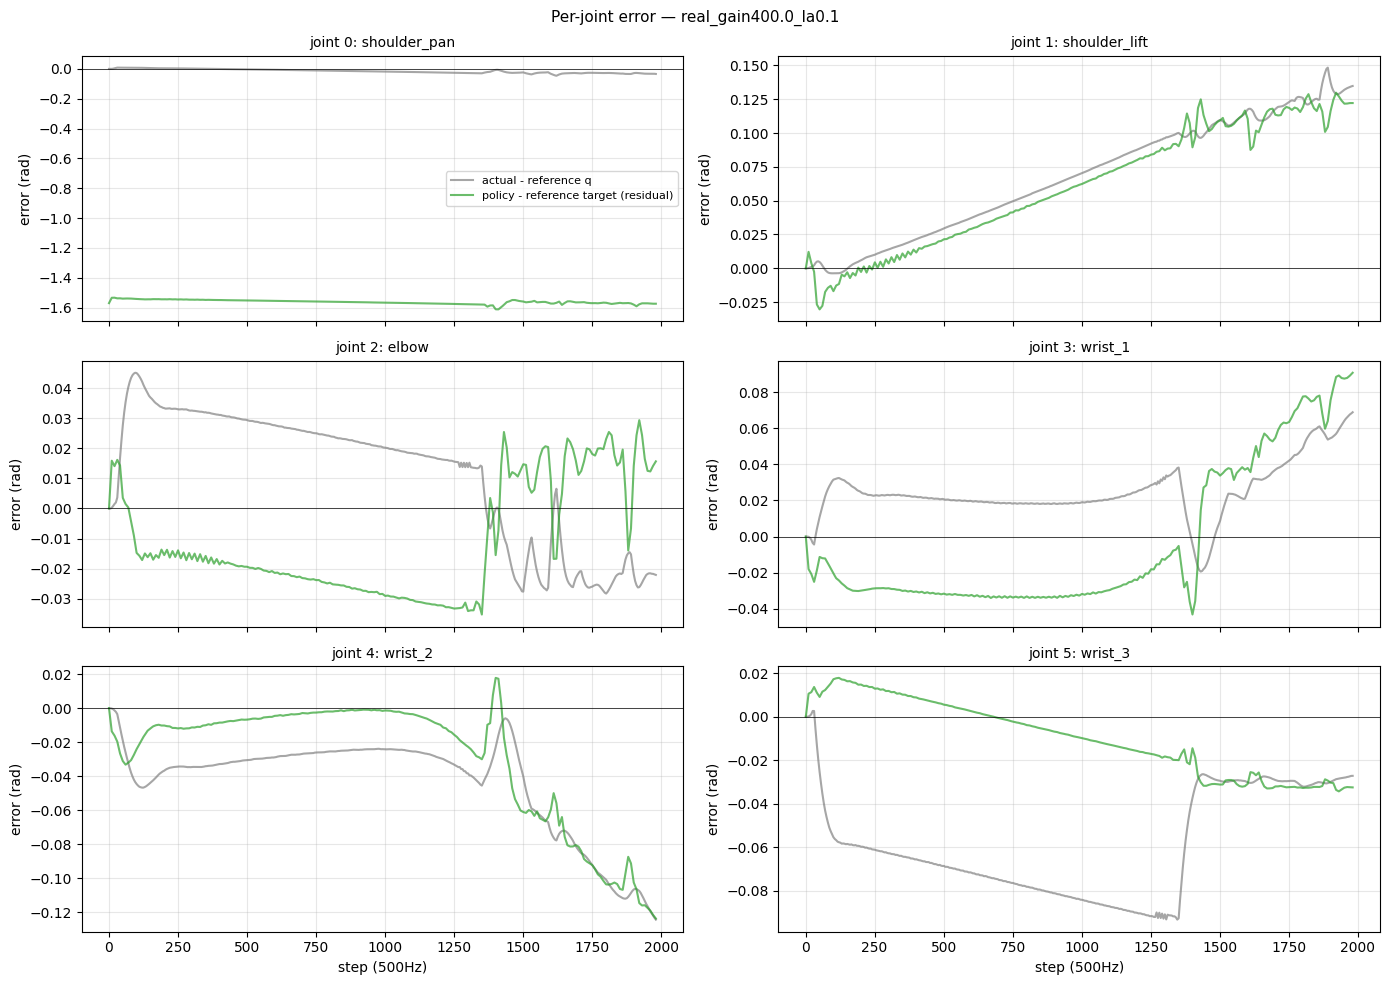

In [4]:
analyze("../logs/rsl_rl/boxpush/2026-04-09_13-03-39_kp150.0_kd22.50_scale0.05/ur_rtde_logs/real_gain400.0_la0.1.npz")

In [5]:
from scipy.interpolate import interp1d

def upsample_linear(x, k):
    N = x.shape[0]
    t_old = np.arange(N)
    t_new = np.linspace(0, N - 1, k * (N - 1) + 1)
    f = interp1d(t_old, x, axis=0, kind="linear")
    return f(t_new)


def analyze_reference(traj_path, alpha=0.1, ds=5):
    """Plot linear-interpolation vs first-order IIR smoothing of the planner's joint targets.

    Both methods upsample the 50 Hz planner waypoints to 500 Hz (decimation=10):
      - linear: piecewise-linear between successive targets (current control-thread behavior)
      - IIR:    y[n] = (1 - alpha) * y[n-1] + alpha * u[n], with u[n] a ZOH of the targets.
                alpha in (0, 1]; smaller = smoother / more lag. alpha=1 collapses to ZOH.
    """
    traj_path = Path(traj_path)
    traj = np.load(traj_path)
    joints_target = traj["joints_target"] if "joints_target" in traj.files else traj["joints_target_l"]
    joints = traj["joints"] if "joints" in traj.files else traj["joints_l"]
    
    joints_target = np.vstack([joints[0:1], joints_target])           # (T+1, 6)
    
    start_i = 150
    joints_target = joints_target[start_i:]
    joints = joints[start_i:]

    decimation = 10  # 50 Hz planner -> 500 Hz control

    # Shared command waveform: starts at joints[0], switches to joints_target[i] at step (i+1)*decimation.
    traj_x = np.arange(len(joints_target)) * decimation               # 0, 10, 20, ...
    ref_steps = np.arange(traj_x[-1] + 1)                          # 0 .. T*decimation

    # --- Linear interpolation (vectorized via np.interp per joint) ---
    linear = upsample_linear(joints_target, decimation)

    # --- First-order IIR low-pass on the ZOH-upsampled command ---
    iir = np.empty_like(linear)
    iir[0] = joints[0]
    one_minus_alpha = 1.0 - alpha
    for i, target in enumerate(joints_target[:-1]):
        for j in range(decimation):
            n = i * decimation + j
            iir[n + 1] = one_minus_alpha * iir[n] + alpha * target

    # --- Plot ---
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    for i, (ax, name) in enumerate(zip(axes.flat, joint_names)):
        ax.plot(traj_x, joints_target[:, i], 'o', markersize=2.5, color='k',
                alpha=0.5, label='planner waypoints')
        ax.plot(ref_steps[::ds], linear[::ds, i], label='linear interp',
                color='tab:green', alpha=0.85)
        ax.plot(ref_steps[::ds], iir[::ds, i], label=f'IIR (\u03b1={alpha})',        
                color='tab:red', alpha=0.85)
        ax.set_title(f"joint {i}: {name}", fontsize=10)
        ax.set_ylabel('position (rad)')
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8, loc='best')
    axes[-1, 0].set_xlabel('step (500Hz)')
    axes[-1, 1].set_xlabel('step (500Hz)')
    fig.suptitle(f"reference joint targets — {traj_path.stem}", fontsize=11)
    plt.tight_layout()


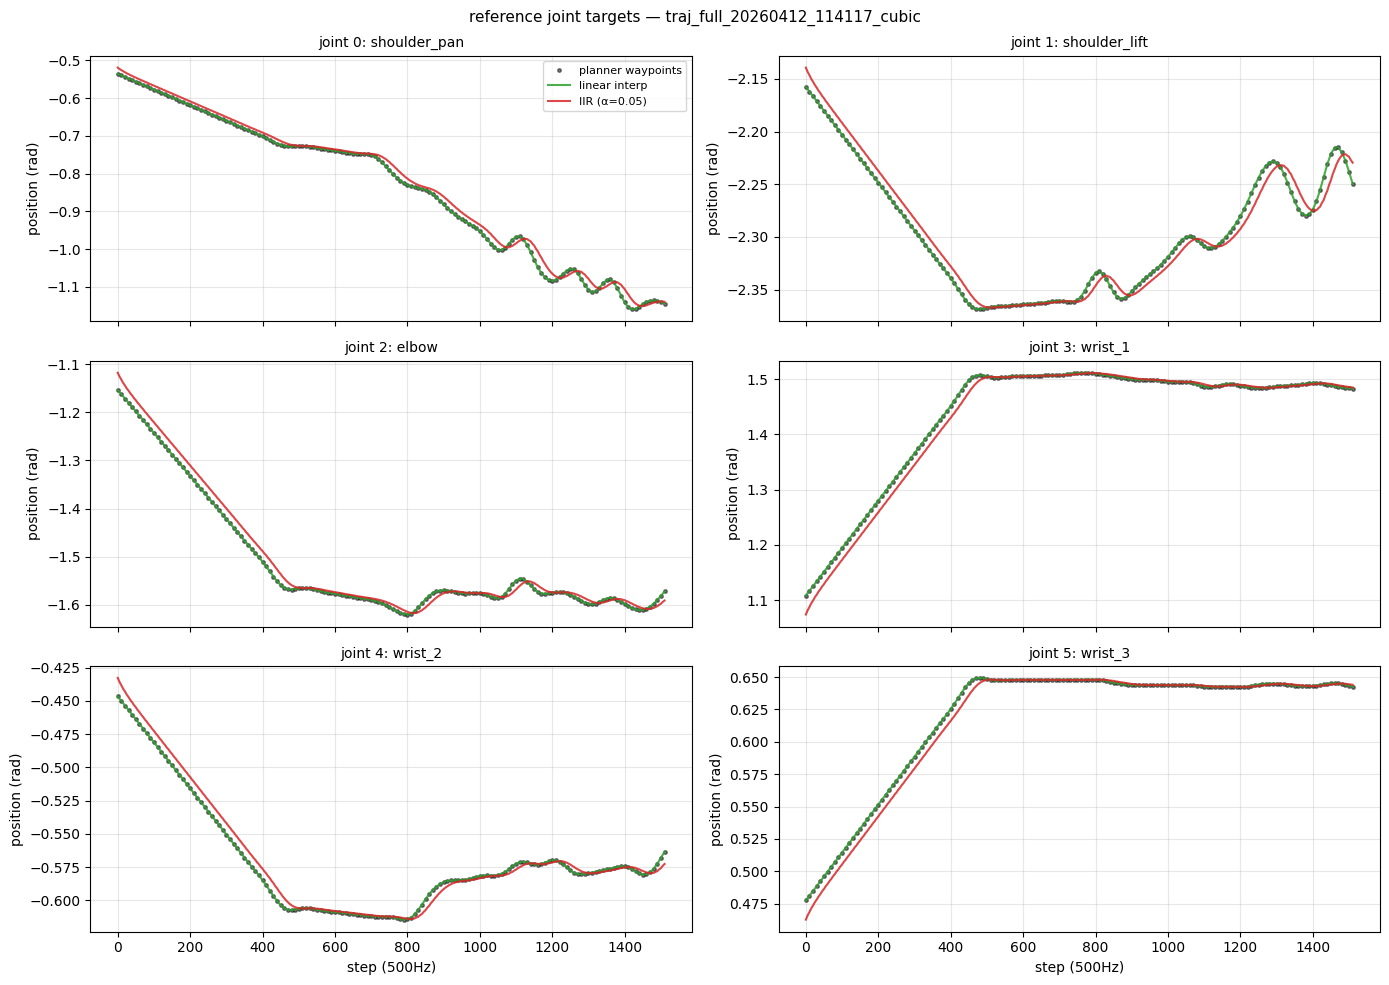

In [6]:
analyze_reference("../reference_trajectories/box_push_ur5e/traj_full_20260412_114117_cubic.npz",ds=5, alpha=0.05)

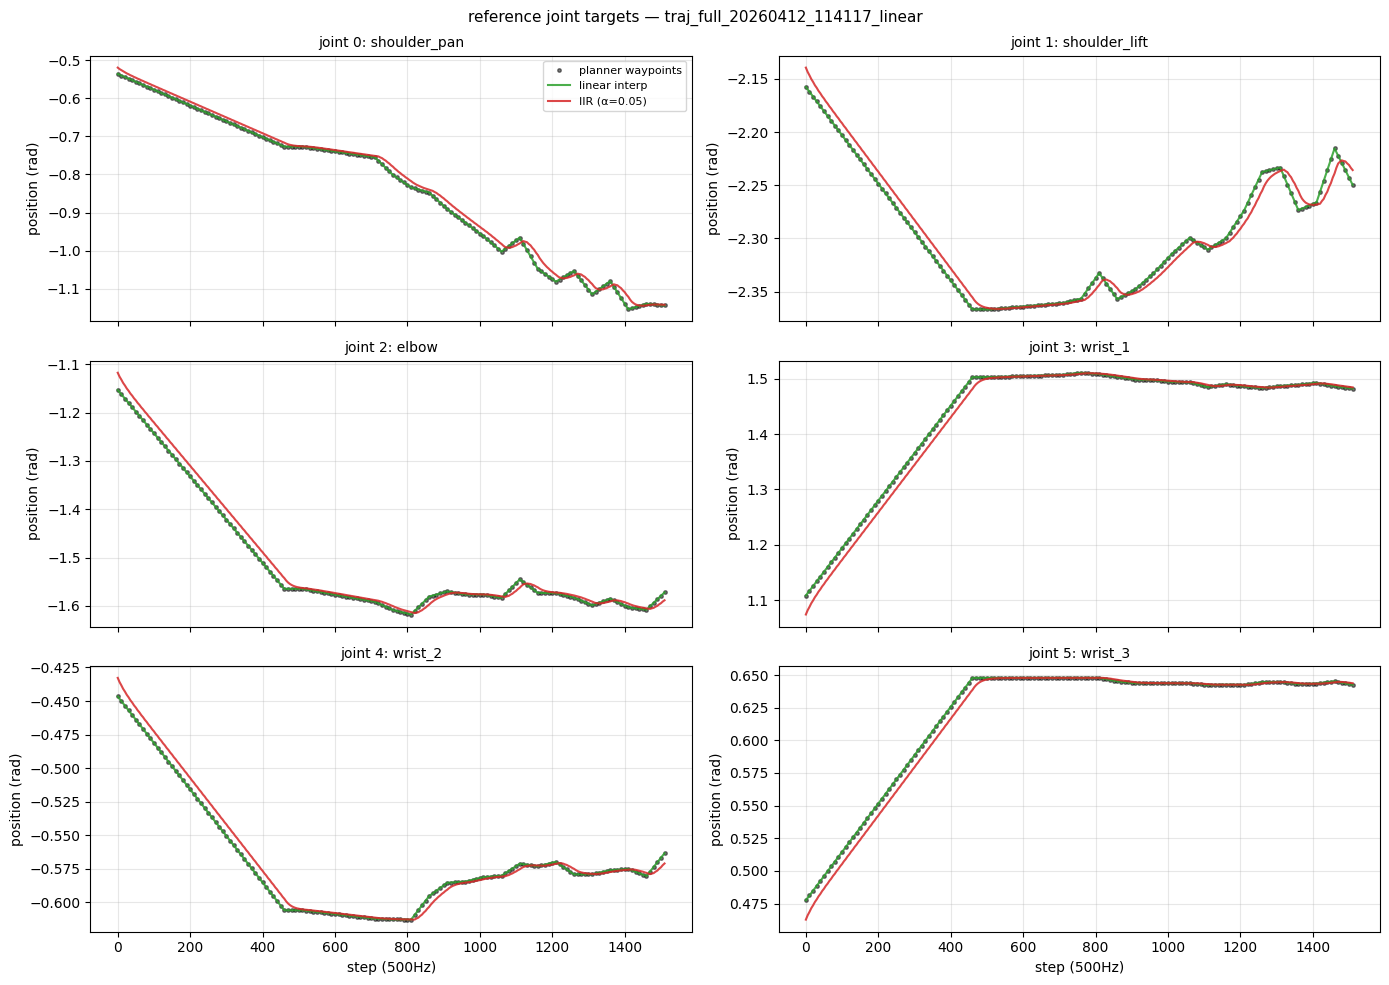

In [7]:
analyze_reference("../reference_trajectories/box_push_ur5e/traj_full_20260412_114117_linear.npz",ds=5, alpha=0.05)

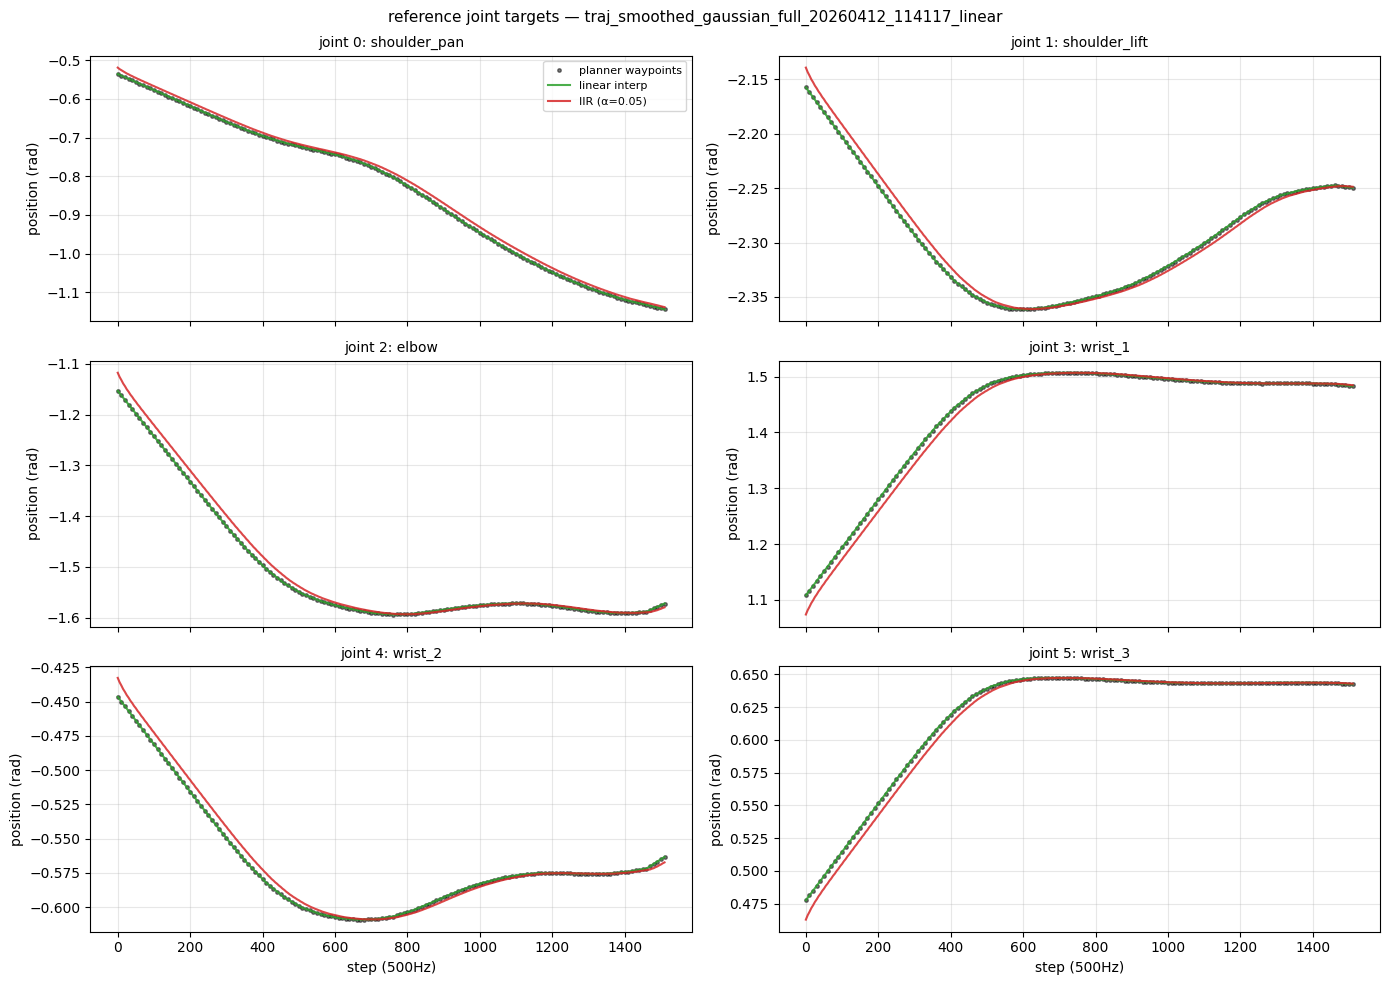

In [8]:
analyze_reference("../reference_trajectories/box_push_ur5e/traj_smoothed_gaussian_full_20260412_114117_linear.npz",ds=5, alpha=0.05)

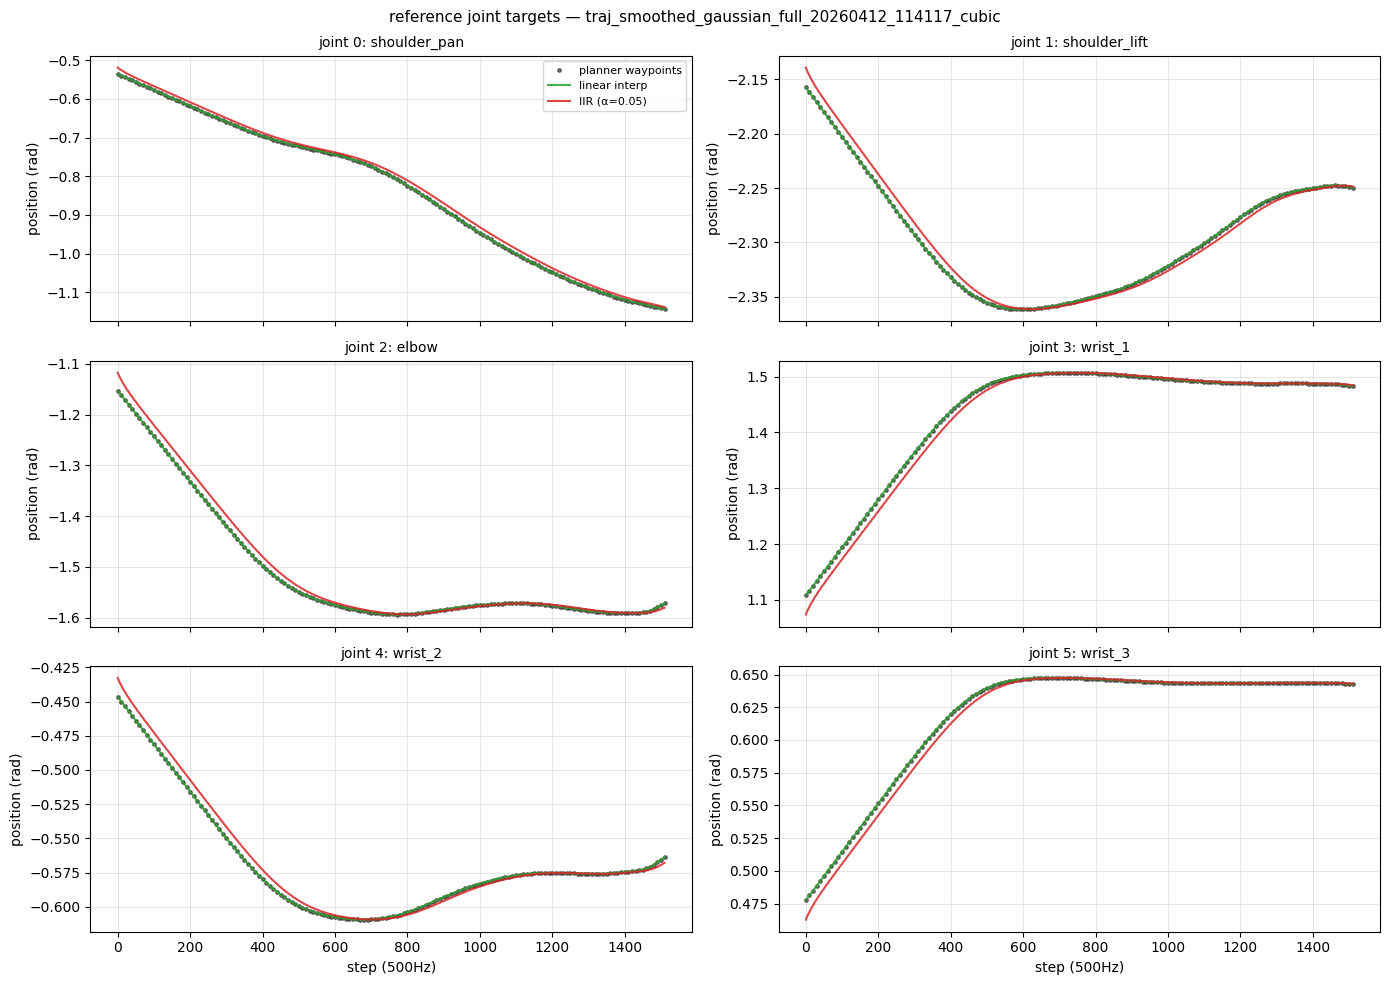

In [9]:
analyze_reference("../reference_trajectories/box_push_ur5e/traj_smoothed_gaussian_full_20260412_114117_cubic.npz",ds=5, alpha=0.05)

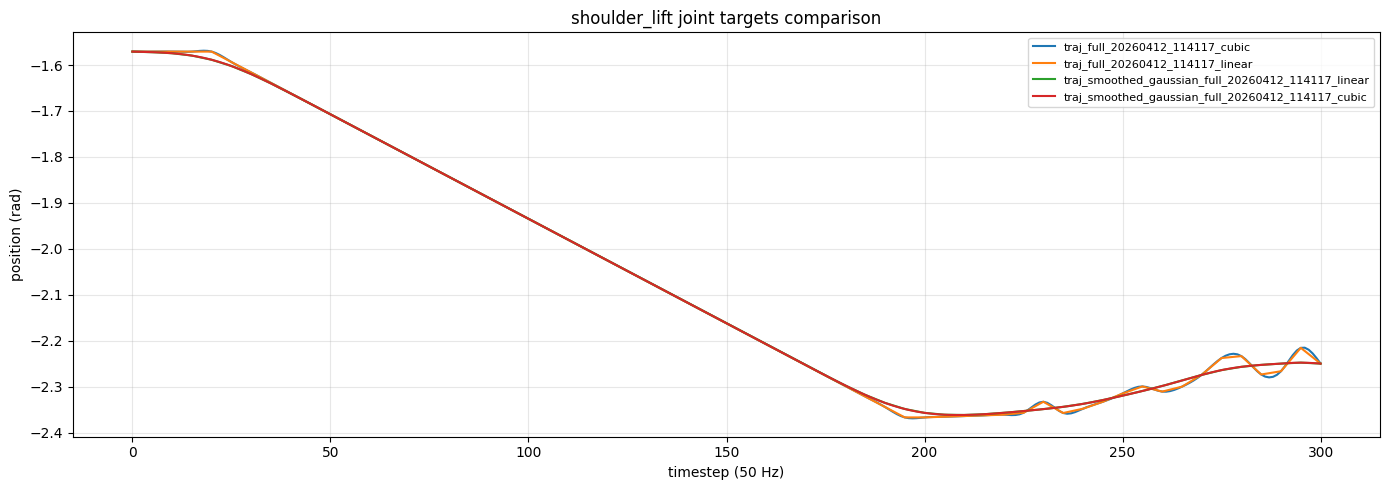

In [ ]:
traj_files = [
    "../reference_trajectories/box_push_ur5e/traj_full_20260412_114117_cubic.npz",
    "../reference_trajectories/box_push_ur5e/traj_full_20260412_114117_linear.npz",
    "../reference_trajectories/box_push_ur5e/traj_smoothed_gaussian_full_20260412_114117_linear.npz",
    "../reference_trajectories/box_push_ur5e/traj_smoothed_gaussian_full_20260412_114117_cubic.npz",
]

start_i = 170

fig, ax = plt.subplots(figsize=(14, 5))
for path in traj_files:
    traj = np.load(path)
    jt = traj["joints_target"] if "joints_target" in traj.files else traj["joints_target_l"]
    ax.plot(jt[start_i:, 1], label=Path(path).stem)
ax.set_xlabel("timestep (50 Hz)")
ax.set_ylabel("position (rad)")
ax.set_title("shoulder_lift joint targets comparison")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()

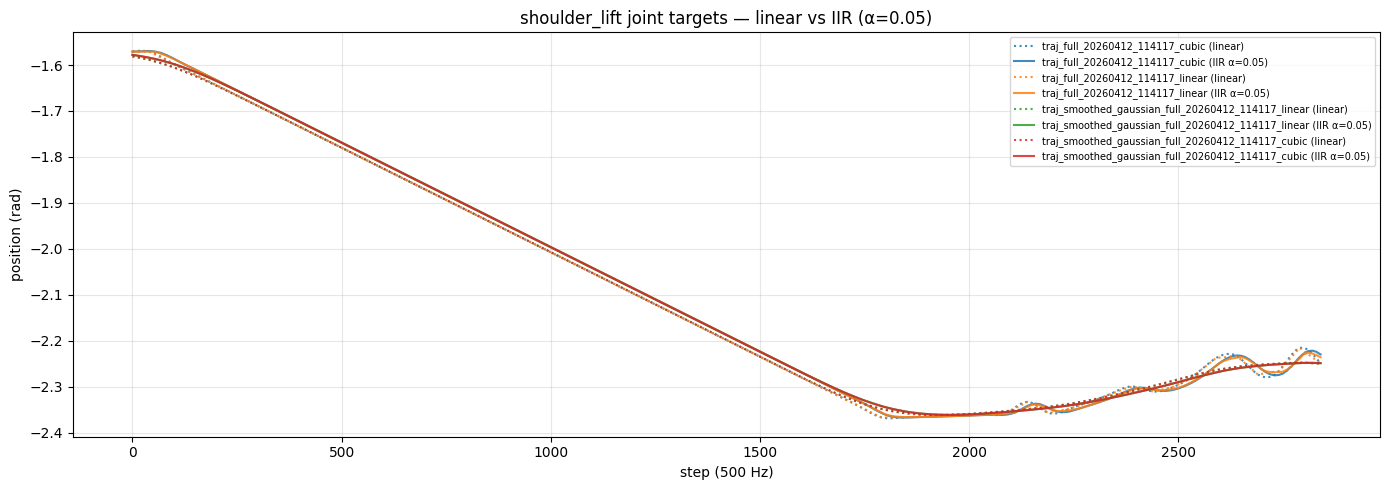

In [ ]:
alpha = 0.05
decimation = 10
joint_idx = 1  # shoulder_lift
start_i = 170

fig, ax = plt.subplots(figsize=(14, 5))
for path in traj_files:
    traj = np.load(path)
    jt = traj["joints_target"] if "joints_target" in traj.files else traj["joints_target_l"]
    joints = traj["joints"] if "joints" in traj.files else traj["joints_l"]
    jt = np.vstack([joints[0:1], jt])

    # Linear interpolation
    linear = upsample_linear(jt, decimation)

    # IIR low-pass
    iir = np.empty_like(linear)
    iir[0] = joints[0]
    for i, target in enumerate(jt[:-1]):
        for j in range(decimation):
            n = i * decimation + j
            iir[n + 1] = (1 - alpha) * iir[n] + alpha * target

    label = Path(path).stem
    color = ax._get_lines.get_next_color()
    ax.plot(linear[:, joint_idx], color=color, linestyle=':', alpha=0.85,
            label=f'{label} (linear)')
    ax.plot(iir[:, joint_idx], color=color, linestyle='-', alpha=0.85,
            label=f'{label} (IIR \u03b1={alpha})')

ax.set_xlabel("step (500 Hz)")
ax.set_ylabel("position (rad)")
ax.set_title(f"shoulder_lift joint targets — linear vs IIR (\u03b1={alpha})")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
plt.tight_layout()